# Virtual dataset reader and plotter
### Example for NASA CMR Shortname: SWOT_L2_LR_SSH_Basic_2.0

#### *Author: Ed Armstrong, PO.DAAC*

*Reference herein to any specific commercial product, process, or service by trade name, trademark, manufacturer, or otherwise, does not constitute or imply its endorsement by the United States Government or the Jet Propulsion Laboratory, California Institute of Technology.*

### Necessary enviroment included
##### earthaccess                   0.16.0
##### fsspec                        2025.9.0
##### kerchunk                      0.2.1
##### numpy                         2.3.3
##### xarray                        2025.1.2
#####  zarr                          2.18.6

In [1]:
# install these versions as needed
#!pip install earthaccess==0.16.0 xarray==2025.1.2 zarr==2.18.6  fsspec>=2025.2 numpy virtualizarr==1.3.2 "numcodecs<0.16.0" kerchunk==0.2.1

In [43]:
pip list | grep -E  -e  '(^xarray|numpy|earthaccess|fsspec|zarr|kerchunk)'

if: Expression Syntax.
then: Command not found.
earthaccess               0.14.0
fsspec                    2024.10.0
kerchunk                  0.2.7
numpy                     2.2.4
virtualizarr              1.3.2
xarray                    2025.1.1
zarr                      2.18.4
Note: you may need to restart the kernel to use updated packages.


In [44]:
# Filesystem management 
import fsspec
import earthaccess

# Data handling
import xarray as xr
import zarr 

# Numpy
import numpy as np

# Other mapping
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

## 1. Earthdata Cloud auth


In [54]:
# Get Earthdata creds
earthaccess.login()

## 2. Perform CMR request for space/time search and Open VDS reference file

The reference can be saved to file and used to open the corresponding CCMP data file with Xarray:

In [72]:
%%time
# Do a CMR granule search and find the orbits in a specific space/time window. SWOT is 0-360 in longitude
lat_min, lat_max = -80, 20
lon_min, lon_max = 0, 120

start_time = '2024-10-03T00:28:00'
end_time = '2024-10-03T23:28:00'

short_name = 'SWOT_L2_LR_SSH_Basic_2.0'
#short_name = 'SCATSAT1_ESDR_L2_WIND_STRESS_V1.1'

granule_result = earthaccess.search_data(
    short_name=short_name,
    temporal=(start_time, end_time),
    bounding_box=(lon_min, lat_min, lon_max, lat_max)
)
print(len(granule_result))

16
CPU times: user 12.2 ms, sys: 3.41 ms, total: 15.6 ms
Wall time: 3.23 s


In [56]:
# Open data using the reference file, using a small wrapper function around xarray's open_dataset. 
# This will shorten code blocks in other sections. 
def get_vds_mapper(vds_link, in_cloud_region=False):
    """
    Produces a virtudal dataset mapper that can be passed to xarray. 
    
    * vds_link: str, link to the mapper
    * in_cloud_region: bool, True if in cloud in the same region as the data, 
        False otherwise.
    """

    if in_cloud_region:
        #fs_data = earthaccess.get_s3_filesystem(daac="PODAAC")
        fs_data = earthaccess.get_s3_filesystem(results=granule_result)
        remote_protocol = "s3"
    else:
        fs_data = earthaccess.get_fsspec_https_session()
        # We set this header to identify usage of the VDS. This helps us support continued development. 
        fs_data.client_kwargs['headers']['User-Agent'] = "virtual-dataset-consumer"
        remote_protocol = "https"
    
    storage_opts = {"fo": vds_link, "remote_protocol": remote_protocol, "remote_options": fs_data.storage_options}
    fs_ref = fsspec.filesystem('reference', **storage_opts)
    return fs_ref.get_mapper('')

In [73]:
%%time

# Path to VDSs, both HTTPS and S3 versions
vds_link ='https://archive.podaac.uat.earthdata.nasa.gov/podaac-uat-cumulus-public/virtual_collections/SWOT_L2_LR_SSH_Basic_2.0/SWOT_L2_LR_SSH_Basic_2.0_virtual_https.json'
#vds_link = 'https://archive.podaac.uat.earthdata.nasa.gov/podaac-uat-cumulus-public/virtual_collections/SWOT_L2_LR_SSH_Basic_2.0/SWOT_L2_LR_SSH_Basic_2.0_virtual_s3.json'
#vds_link = '/Users/earmstro/Downloads/SCATSAT1_ESDR_L2_WIND_STRESS_V1.1_virtual_https.json'

# Lets open the JSON VDS
vds_mapper = get_vds_mapper(vds_link, in_cloud_region=False)

## No modification needed!
data_vds = xr.open_dataset(
    vds_mapper, engine="zarr", chunks={},
    backend_kwargs={"consolidated": False}
)
data_vds
#print(data)


CPU times: user 166 ms, sys: 9.66 ms, total: 176 ms
Wall time: 3.13 s


<xarray.Dataset> Size: 2TB
Dimensions:                                (orbit: 18374, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    latitude                               (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude                              (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
  * orbit                                  (orbit) datetime64[ns] 147kB 2023-...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    ancillary_surface_classification_flag  (orbit, num_lines, num_pixels) float32 50GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    distance_to_coast                      (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    dynamic_ice_flag                       (orbit, num_lines, num_pixels) float32 50GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    geoid                                  (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    heading_to_coast                       (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    height_cor_xover                       (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ...                                     ...
    ssha_karin                             (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2                           (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2_qual                      (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_qual                        (orbit, num_lines, num_pixels) float64 100GB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    time                                   (orbit, num_lines) datetime64[ns] 1GB dask.array<chunksize=(1, 9866), meta=np.ndarray>
    time_tai                               (orbit, num_lines) datetime64[ns] 1GB dask.array<chunksize=(1, 9866), meta=np.ndarray>
Attributes: (12/17)
    Conventions:                 CF-1.7
    title:                       Level 2 Low Rate Sea Surface Height Data Pro...
    source:                      Ka-band radar interferometer
    platform:                    SWOT
    reference_document:          D-56407_SWOT_Product_Description_L2_LR_SSH
    short_name:                  L2_LR_SSH
    ...                          ...
    transmit_antenna:            minus_y
    xref_statickarincal_files:   SWOT_StaticKaRInCalAdjustableParam_20000101T...
    xref_reforbittrack_files:    SWOT_RefOrbitTrack125mPass1_Nom_20000101T000...
    xref_geco_database_version:  v102
    ellipsoid_semi_major_axis:   6378137.0
    ellipsoid_flattening:        0.0033528106647474805

## 3. Use granule metadata to find the start times of the  orbits and use  to subset into the VDS

In [74]:
# Get granule start times from CMR granule search result. Will be used to subset into the VDS:
datetimes_str = [g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime'][:-1] for g in granule_result]  # -1 to remove "Z" at end.
datetimes_obj = [np.datetime64(dts) for dts in datetimes_str]
print(datetimes_obj)

[np.datetime64('2024-10-02T23:55:22.399'), np.datetime64('2024-10-03T00:46:49.246'), np.datetime64('2024-10-03T01:38:16.030'), np.datetime64('2024-10-03T02:29:42.892'), np.datetime64('2024-10-03T04:12:36.589'), np.datetime64('2024-10-03T05:55:30.318'), np.datetime64('2024-10-03T07:38:23.986'), np.datetime64('2024-10-03T13:38:31.508'), np.datetime64('2024-10-03T15:21:25.233'), np.datetime64('2024-10-03T17:04:18.995'), np.datetime64('2024-10-03T18:47:12.685'), np.datetime64('2024-10-03T19:38:39.519'), np.datetime64('2024-10-03T20:30:06.298'), np.datetime64('2024-10-03T21:21:33.090'), np.datetime64('2024-10-03T22:12:59.862'), np.datetime64('2024-10-03T23:04:26.654')]


In [77]:
# Subset into VDS ---- THIS DOES NOT WORK....the orbits represented by datetime_obj are not consecutive....re indexing does not work
#data_vds_subset = data_vds.sel(orbit = datetimes_obj)
#data_vds_subset


In [78]:
# Mask (and subset)the entire VDS with the orbits found from the CMR space/time query and granule metadata parsing for start times
mask = data_vds.orbit.isin(datetimes_obj)
data_vds_subset = data_vds.where(mask, drop=True)
data_vds_subset

<xarray.Dataset> Size: 2GB
Dimensions:                                (orbit: 16, num_lines: 9866,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    latitude                               (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    longitude                              (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
  * orbit                                  (orbit) datetime64[ns] 128B 2024-1...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    ancillary_surface_classification_flag  (orbit, num_lines, num_pixels) float32 44MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    distance_to_coast                      (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    dynamic_ice_flag                       (orbit, num_lines, num_pixels) float32 44MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    geoid                                  (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    heading_to_coast                       (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    height_cor_xover                       (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ...                                     ...
    ssha_karin                             (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2                           (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_2_qual                      (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    ssha_karin_qual                        (orbit, num_lines, num_pixels) float64 87MB dask.array<chunksize=(1, 9866, 69), meta=np.ndarray>
    time                                   (orbit, num_lines) datetime64[ns] 1MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
    time_tai                               (orbit, num_lines) datetime64[ns] 1MB dask.array<chunksize=(1, 9866), meta=np.ndarray>
Attributes: (12/17)
    Conventions:                 CF-1.7
    title:                       Level 2 Low Rate Sea Surface Height Data Pro...
    source:                      Ka-band radar interferometer
    platform:                    SWOT
    reference_document:          D-56407_SWOT_Product_Description_L2_LR_SSH
    short_name:                  L2_LR_SSH
    ...                          ...
    transmit_antenna:            minus_y
    xref_statickarincal_files:   SWOT_StaticKaRInCalAdjustableParam_20000101T...
    xref_reforbittrack_files:    SWOT_RefOrbitTrack125mPass1_Nom_20000101T000...
    xref_geco_database_version:  v102
    ellipsoid_semi_major_axis:   6378137.0
    ellipsoid_flattening:        0.0033528106647474805

## 4. Mask the data and plot

In [79]:
# Perform SSH variable maskings for the large numeric  "fill_values" and other assignments
ssh = data_vds_subset.ssh_karin
ssh = ssh.where(ssh < 1000)

lat = data_vds_subset.latitude
lon = data_vds_subset.longitude

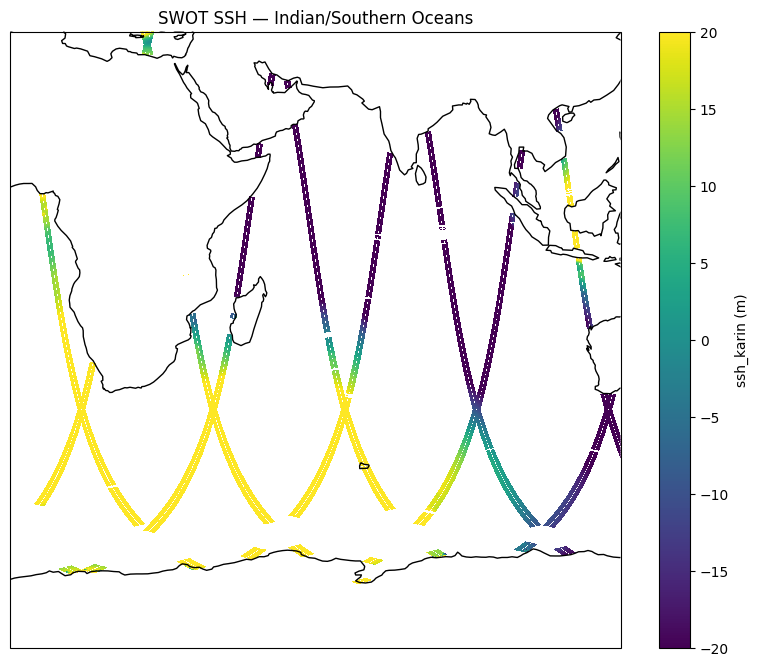

CPU times: user 13.4 s, sys: 1.39 s, total: 14.8 s
Wall time: 48.3 s


In [80]:
%%time
# Do the spatial plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.coastlines()

for k in range(ssh.sizes["orbit"]):
    ssh_i = ssh.isel(orbit=k).load()
    lat_i = lat.isel(orbit=k).load()
    lon_i = lon.isel(orbit=k).load()
    
    pcm = ax.pcolormesh(
        lon_i,
        lat_i,
        ssh_i,
        shading="auto",
        cmap="viridis",
        vmin=-20,
        vmax=20,
        transform=ccrs.PlateCarree()
    )

plt.colorbar(pcm, ax=ax, label="ssh_karin (m)")
plt.title("SWOT SSH — Indian/Southern Oceans")
plt.show()